In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder\
.master('local[*]')\
.getOrCreate()
sc = spark.sparkContext

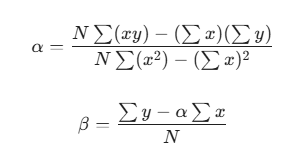

In [2]:
#1 데이터 준비: (x,y)
data = [
    (1,2), (2,4), (3,6), (4,8)
]
rdd = sc.parallelize(data)

In [3]:
#Map 단계- 필요한 항들을 미리 계산해서 튜플로 묶기
#(x,y) -> (x,y,x*y,x^2, 1)
#마지막 1은 개수를 세기 위한(N)

rdd2 = rdd.map(lambda p : (p[0], p[1], p[0]*p[1], p[0]**2, 1))

In [5]:
#Reduce 단계 - 각 항을 모두 더하기(sigma)
#(sum_x, sum_y, sum_xy, sum_xx, N)
rdd3 = rdd2.reduce(lambda a,b:(
    a[0]+b[0],
    a[1]+b[1],
    a[2]+b[2],
    a[3]+b[3],
    a[4]+b[4]
))

#결과값 언패킹
sum_x, sum_y, sum_xy, sum_xx, n = rdd3

In [6]:
#수식적용
분모 = (n*sum_xx) - (sum_x **2)
#기울기 alpha
alpha = (n*sum_xy - sum_x * sum_y) / 분모
#절편 beta
beta = (sum_y - alpha*sum_x)/n
print(f"예측 모델: y = {alpha:.2f}x + {beta:.2f}")

예측 모델: y = 2.00x + 0.00
